In [1]:
!python -V

Python 3.9.12


In [16]:
# import ML deps
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import root_mean_squared_error, mean_squared_error

In [ ]:
# set ML experiment tracking
import mlflow

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('demo-experiment-nyc-taxi-pred')

2026/06/18 21:27:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/18 21:27:07 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2026/06/18 21:27:07 INFO mlflow.tracking.fluent: Experiment with name 'demo-experiment-nyc-taxi-pred' does not exist. Creating a new experiment.


<Experiment: artifact_location='/workspaces/learning-MLOps/mlops-zoomcamp/mlruns/1', creation_time=1781818027744, experiment_id='1', last_update_time=1781818027744, lifecycle_stage='active', name='demo-experiment-nyc-taxi-pred', tags={}>

In [ ]:
# ingest & read data
df = pd.read_parquet('./data/green_tripdata_2026-01.parquet')

In [ ]:
# inspect data
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,N,1.0,65,233,2.0,6.20,31.7,...,1.5,7.5,0.0,NaN,1.0,45.20,1.0,1.0,2.75,0.75
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5.0,66,188,5.0,5.36,50.0,...,0.0,10.2,0.0,NaN,1.0,61.20,1.0,2.0,0.00,0.00
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,N,1.0,65,179,4.0,10.60,41.5,...,1.5,2.0,0.0,NaN,1.0,46.00,1.0,1.0,0.00,0.00
3,1,2026-01-01 00:44:33,2026-01-01 01:00:45,N,1.0,42,141,1.0,4.20,19.8,...,1.5,0.0,0.0,NaN,1.0,25.05,2.0,1.0,2.75,0.00
4,2,2026-01-01 00:46:04,2026-01-01 01:04:40,N,1.0,95,82,1.0,2.76,19.1,...,0.5,0.0,0.0,NaN,1.0,21.60,2.0,1.0,0.00,0.00


#### modelling #1

In [ ]:
# data prep
df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [ ]:
# feature selection
train_dicts = df[categorical + numerical].to_dict(orient='records')
target = 'duration'

# set train set 
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)
y_train = df[target].values

# model
lr = LinearRegression()
lr.fit(X_train, y_train)

# predict
y_pred = lr.predict(X_train)

# eval
root_mean_squared_error(y_train, y_pred)

8.048606200417199

/tmp/ipykernel_19170/1196719062.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/tmp/ipykernel_19170/1196719062.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label='actual')


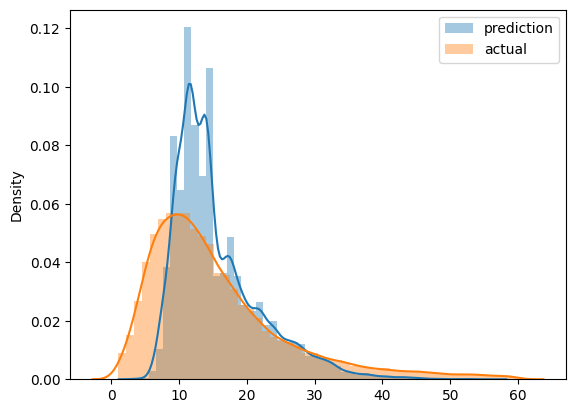

In [16]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

plt.legend();

#### modelling #2 (cleaner)

In [9]:
# data wrangling func
def read_dataframe(filename) -> pd.DataFrame:
    if filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [11]:
# ingest data 
df_train = read_dataframe('./data/green_tripdata_2026-01.parquet')
df_val = read_dataframe('./data/green_tripdata_2026-02.parquet')

# feature engineering | gotten from EDA
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [13]:
# feature selection
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID'] new feature selction
numerical = ['trip_distance']
target = 'duration'


# train and val set 
dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
val_dicts = df_val[categorical + numerical].to_dict(orient='records')

X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)

y_train = df_train[target].values
y_val = df_val[target].values

In [14]:
# model
lr = LinearRegression()
lr.fit(X_train, y_train)

# predict
y_pred = lr.predict(X_val)

# eval
root_mean_squared_error(y_val, y_pred)

7.108783270850662

In [27]:
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [15]:
lr = Lasso(0.01)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

9.105442824302282

#### Implementing MLFlow

In [18]:
with mlflow.start_run():
    
    mlflow.set_tag('developer', 'willcodes')

    # log train and val data paths as params
    mlflow.log_param('train-data-path', './data/green_tripdata_2026-01.parquet')
    mlflow.log_param('val-data-path', './data/green_tripdata_2026-02.parquet')

    # log hyperparam
    alpha = .01 
    mlflow.log_param('alpha', alpha)

    # model
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)
    
    # pred
    y_pred = lr.predict(X_val)

    # eval
    rmse = mean_squared_error(y_val, y_pred)

    # log eval metric
    mlflow.log_metric('rmse', rmse)
    